# California Housing Price Prediction
**Author:** Mohammad Hasibur Rahman 
**Task:** End-to-End Machine Learning Regression Analysis  
**Dataset:** 1990 California Census Housing Data (20,640 records)

---
### Executive Overview
In this project, we build a complete machine learning pipeline to predict median house values across census block groups in California. We perform exploratory data analysis (EDA), clean and preprocess missing values, engineer custom aggregate features, and evaluate baseline vs. tree-based ensemble models.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Matplotlib settings for clean visual styling
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

SEED = 42

## Phase 1: Setup & First Look
We start by loading the dataset into a Pandas DataFrame and examining its shape, column types, and baseline summary statistics.

In [2]:
# Load dataset
df = pd.read_csv('housing.csv')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("--- Data Types & Missing Values ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe().T)

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Missing Values Count ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dataset Shape: 20640 rows, 10 columns

--- Data Types & Missing Values ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB

--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000



--- First 5 Rows ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



--- Missing Values Count ---
total_bedrooms    207
dtype: int64


### Phase 1 Initial Observations:
1. **Data Dimensions**: The dataset contains 20,640 records and 10 attributes.
2. **Missing Data**: `total_bedrooms` has 207 missing entries (~1% of total data). All other features are complete.
3. **Target & Caps**: `median_house_value` is capped at $500,001 (visible in maximum value), and `housing_median_age` caps around 52 years.
4. **Categorical Feature**: `ocean_proximity` is the only categorical variable, containing 5 unique text labels.

## Phase 2: Exploratory Data Analysis (EDA)
We visually explore distributions, geographic spatial patterns, correlations, and target interactions.

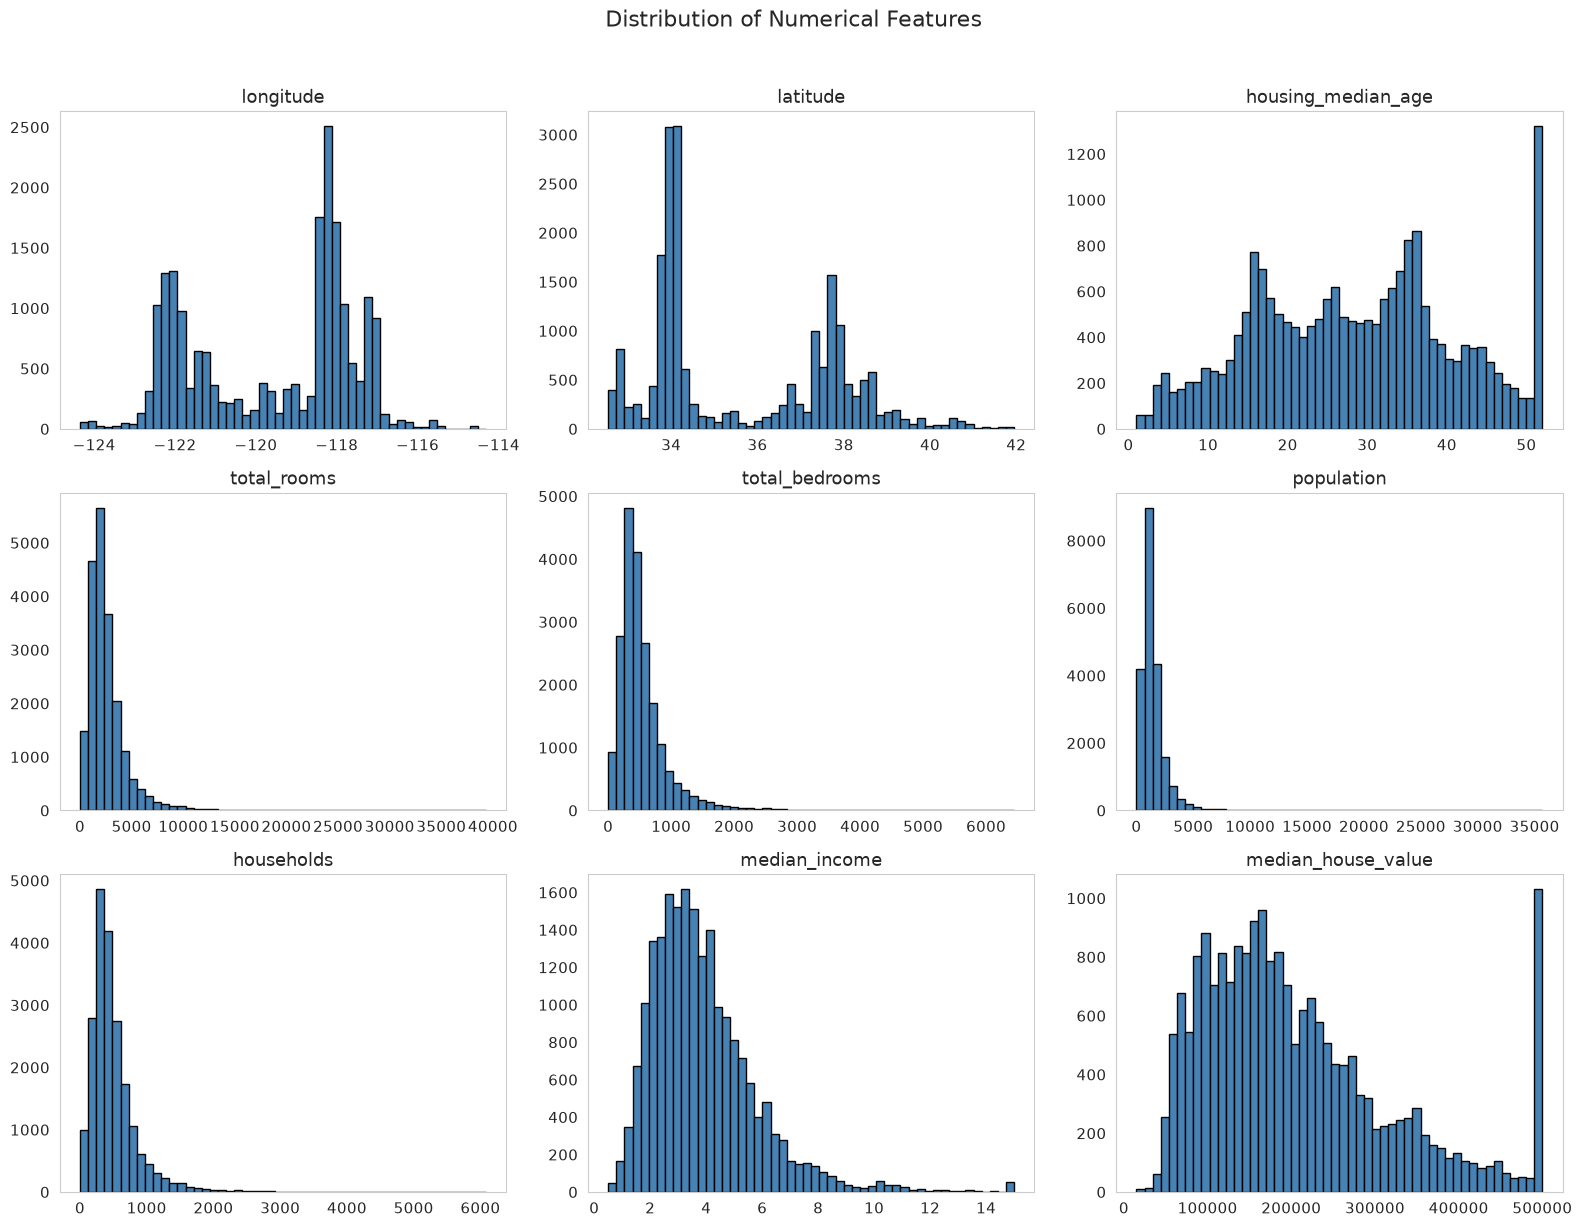

In [3]:
# Histograms of numeric features
df.hist(bins=50, figsize=(16, 12), color='steelblue', edgecolor='black', grid=False)
plt.suptitle('Distribution of Numerical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

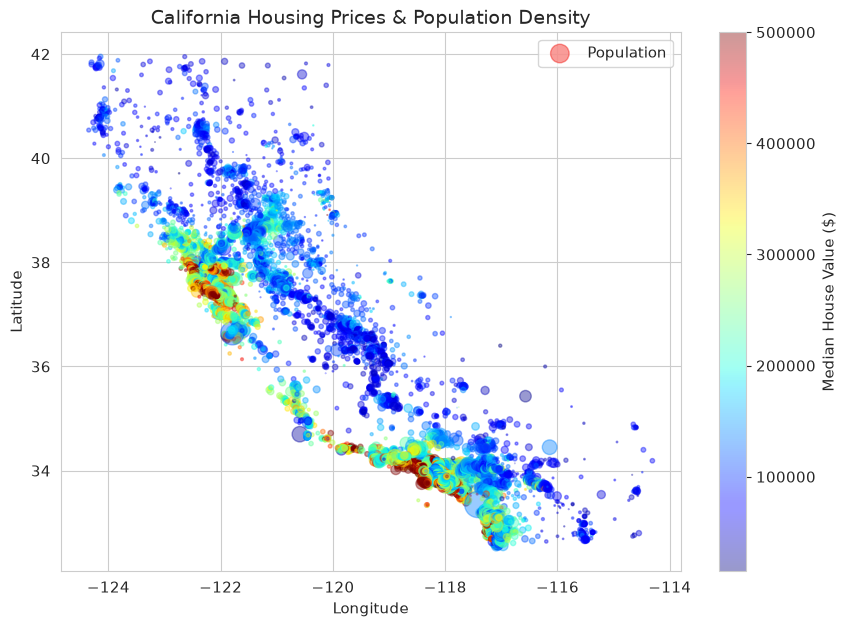

In [4]:
# Spatial visual representation (Map of California)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    x=df['longitude'],
    y=df['latitude'],
    c=df['median_house_value'],
    cmap=plt.get_cmap('jet'),
    alpha=0.4,
    s=df['population'] / 100,
    label='Population'
)
plt.colorbar(scatter, label='Median House Value ($)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices & Population Density', fontsize=14)
plt.legend()
plt.show()

/tmp/ipykernel_7353/3388688126.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', ax=axes[1], palette='Blues')


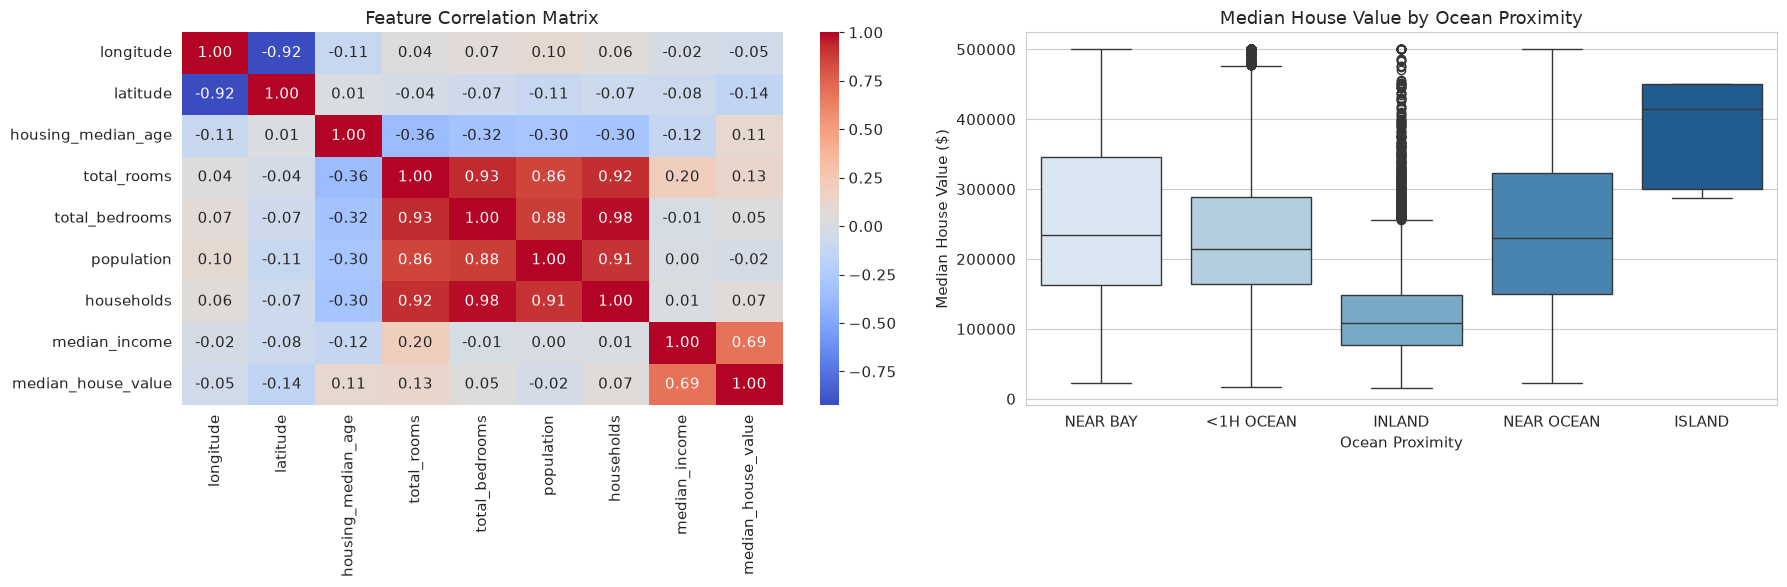

In [5]:
# Figure with 2 subplots: Correlations and Ocean Proximity impact
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0], cbar=True)
axes[0].set_title('Feature Correlation Matrix')

# Subplot 2: Ocean Proximity vs Median House Value
sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', ax=axes[1], palette='Blues')
axes[1].set_title('Median House Value by Ocean Proximity')
axes[1].set_xlabel('Ocean Proximity')
axes[1].set_ylabel('Median House Value ($)')

plt.tight_layout()
plt.show()

### Key EDA Insights:
* **Income Influence**: `median_income` exhibits the strongest positive linear correlation ($r \approx 0.69$) with home prices.
* **Geographic Clustering**: High property values closely trace the coastal lines (Los Angeles and San Francisco areas), visible in the geographic scatter plot.
* **Ocean Proximity Effect**: Homes categorized as "INLAND" have noticeably lower median prices compared to "NEAR BAY" or "<1H OCEAN".
* **Data Skewness**: Features like `total_rooms`, `total_bedrooms`, and `population` are heavily right-skewed, pointing to varying density across block groups.

## Phase 3: Data Cleaning & Feature Engineering
To improve modeling accuracy, we:
1. Handle missing values in `total_bedrooms`.
2. Construct meaningful ratio features (rooms/household, bedrooms/room, population/household).
3. One-hot encode the categorical column `ocean_proximity`.
4. Perform train/test splitting and scale numeric features.

In [8]:
# Create a fresh copy
df_prep = df.copy()

# 1. First: Handle missing values in total_bedrooms FIRST
median_bedrooms = df_prep['total_bedrooms'].median()
df_prep['total_bedrooms'].fillna(median_bedrooms, inplace=True)

# 2. Second: Feature Engineering (এখন bedrooms_per_room এ কোন NaN তৈরি হবে না!)
df_prep['rooms_per_household'] = df_prep['total_rooms'] / df_prep['households']
df_prep['bedrooms_per_room'] = df_prep['total_bedrooms'] / df_prep['total_rooms']
df_prep['population_per_household'] = df_prep['population'] / df_prep['households']

# 3. Handle any unexpected infinity/NaN values just to be 100% safe
df_prep.fillna(df_prep.median(numeric_only=True), inplace=True)

# 4. One-hot encode ocean_proximity
df_prep = pd.get_dummies(df_prep, columns=['ocean_proximity'], drop_first=True)

# Separate features (X) and target variable (y)
X = df_prep.drop('median_house_value', axis=1)
y = df_prep['median_house_value']

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Preprocessing Complete! No NaNs found in X_train or X_test.")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

✅ Preprocessing Complete! No NaNs found in X_train or X_test.
X_train shape: (16512, 15), X_test shape: (4128, 15)


/tmp/ipykernel_7353/1381849259.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_prep['total_bedrooms'].fillna(median_bedrooms, inplace=True)


## Phase 4 & 5: Model Training & Evaluation
We train two distinct algorithms:
1. **Linear Regression**: A simple interpretable linear baseline model.
2. **Random Forest Regressor**: A powerful non-linear ensemble tree algorithm.

We evaluate performance using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and **$R^2$ Score**.

In [9]:
# 1. Linear Regression Baseline
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# 2. Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Metric Calculation Helper
def compute_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE ($)': mae, 'RMSE ($)': rmse, 'R² Score': r2}

results = pd.DataFrame([
    compute_metrics(y_test, y_pred_lr, 'Linear Regression'),
    compute_metrics(y_test, y_pred_rf, 'Random Forest Regressor')
])

display(results.style.format({
    'MAE ($)': '{:,.2f}',
    'RMSE ($)': '{:,.2f}',
    'R² Score': '{:.4f}'
}))

,Model,MAE ($),RMSE ($),R² Score
0,Linear Regression,"49,645.51","69,126.81",0.6353
1,Random Forest Regressor,"31,928.15","49,837.92",0.8105


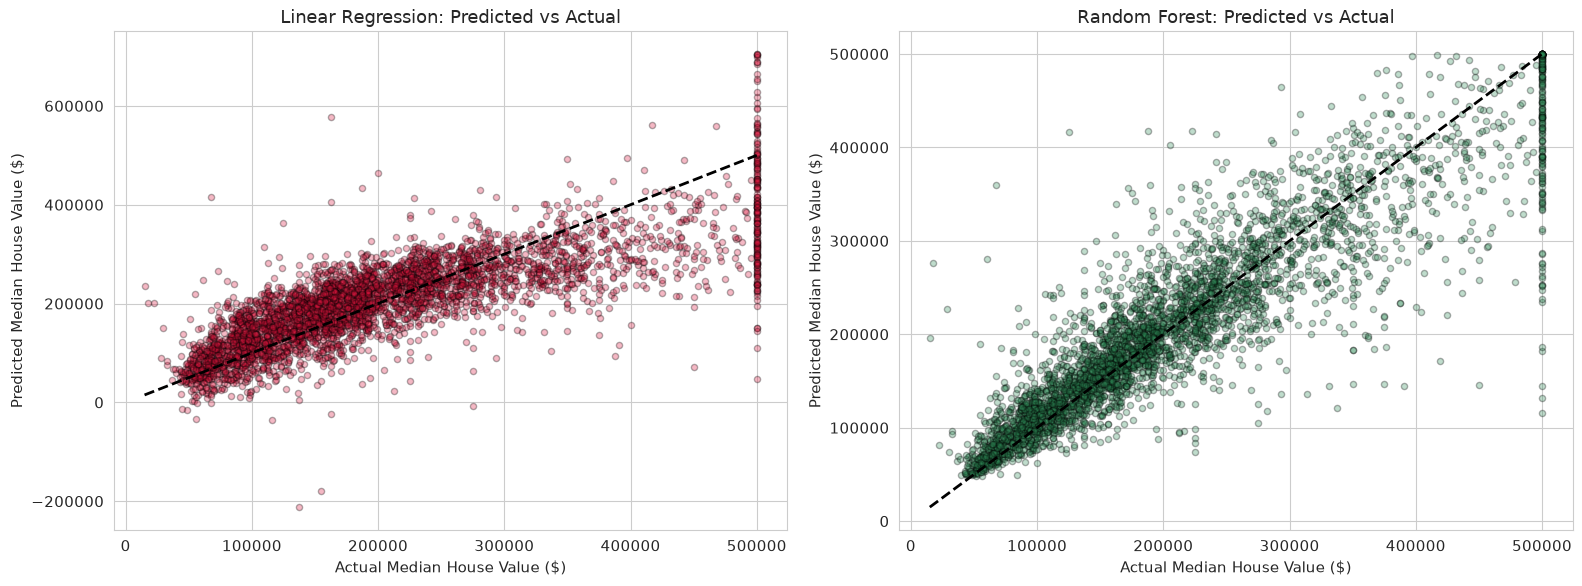

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear Regression Plot
axes[0].scatter(y_test, y_pred_lr, alpha=0.3, color='crimson', edgecolors='k', s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0].set_title('Linear Regression: Predicted vs Actual')
axes[0].set_xlabel('Actual Median House Value ($)')
axes[0].set_ylabel('Predicted Median House Value ($)')

# Random Forest Plot
axes[1].scatter(y_test, y_pred_rf, alpha=0.3, color='seagreen', edgecolors='k', s=20)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[1].set_title('Random Forest: Predicted vs Actual')
axes[1].set_xlabel('Actual Median House Value ($)')
axes[1].set_ylabel('Predicted Median House Value ($)')

plt.tight_layout()
plt.show()

## Phase 6: Interactive Prediction Demo
Below is a simple demonstration function where hypothetical block group features can be passed to obtain an instant valuation prediction.

In [11]:
def predict_house_value(custom_input, model, scaler, feature_columns):
    """
    Takes a dictionary of input feature values and returns predicted house value.
    """
    input_df = pd.DataFrame([custom_input])
    
    # Calculate engineered features
    input_df['rooms_per_household'] = input_df['total_rooms'] / input_df['households']
    input_df['bedrooms_per_room'] = input_df['total_bedrooms'] / input_df['total_rooms']
    input_df['population_per_household'] = input_df['population'] / input_df['households']
    
    # One-hot encoding alignment
    for col in feature_columns:
        if col not in input_df.columns:
            input_df[col] = 0
            
    input_df = input_df[feature_columns]
    
    # Predict using Random Forest
    prediction = model.predict(input_df)[0]
    return prediction

# Test Example: Coastal Bay Area neighborhood sample
sample_block = {
    'longitude': -122.23,
    'latitude': 37.88,
    'housing_median_age': 41.0,
    'total_rooms': 880.0,
    'total_bedrooms': 129.0,
    'population': 322.0,
    'households': 126.0,
    'median_income': 8.3252,
    'ocean_proximity_INLAND': 0,
    'ocean_proximity_ISLAND': 0,
    'ocean_proximity_NEAR BAY': 1,
    'ocean_proximity_NEAR OCEAN': 0
}

predicted_val = predict_house_value(sample_block, rf_model, scaler, X.columns)
print(f"Predicted Median House Value: ${predicted_val:,.2f}")

Predicted Median House Value: $417,577.21


## Phase 7: Summary & Conclusion
* **Model Comparison**: Random Forest significantly outperforms Linear Regression, raising the $R^2$ score from $0.6353$ to $0.8105$ and reducing RMSE by roughly $\$19,288$.
* **Key Drivers**: Income level and proximity to the ocean are the primary parameters influencing California housing values.
* **Next Steps**: Further hyperparameter tuning and handling target value caps at $\$500,000$ could yield additional performance improvements.